This notebook demonstrates using the Sitka Data Viewer within a Jupyter Notebook.

Sitka is an interactive viewer for HDF5 files and Zarr stores.  Using it from 
Jupyter allows you to 
   1.  use the GUI to browse and explore the data and choose which datasets and arrays to work with in the Jupyter session.
   2.  push nd-arrays from your Jupyter notebook into the Sitka GUI, allowing you to use it for visualization and exporting multiple arrays to HDF5 files.


Since you can easily move data between the Jupyter session and the Sitka viewer, you can use Sitka as a visualization and extraction tool for nd-arrays in your Jupyter notebooks.

In [1]:
# Step 0: if not already downloaded, get the Sitka example files
import os
from pathlib import Path
xrfmap1 = Path('xrf_map_seed.h5')
if not xrfmap1.exists():
    print("Downloading Sitka Examples")
    import get_sitka_examples

filelist = os.listdir('.')
print("Files: ", filelist)

Files:  ['jupyter_sitka.py', 'Eiger9M_example.h5', 'get_sitka_examples.py', '.DS_Store', 'u', 'jupyter_sitka.ipynb', '__pycache__', 's', 'UL3_HERFD.h5', 'xrf_map_seed.h5', '.virtual_documents', 'Fe_abs_corr.larix', 'sitka_examples.zip', '.ipynb_checkpoints', 'z1.zarr']


In [2]:
# Step 1: import and start the Sitka Viewer
# This will show the Sitka GUI in a separate window, 
# and read in all the data HDF5/Zarr files in the current folder.

from sitka_spruce import sitka_viewer, SitkaFrame
sview = sitka_viewer(folder='.')

In [4]:
# The Sitka Viewer holds its data in the `data` attribute of the Sitka_Viewer, this has a
# has a few useful attributes.  
# 
# And the Sitka Viewer has a few useful methods for accessing its data:
# First, its "data" attribute really holds the data and can be accessed with:
#    data.datasets           dict of {Filename: Data Object (h5py.File or zarr.Group)}
#    data.arrays             dict of {Name: ndarray} for named arrays
#    data.array_addrs        dict of {Name: access string} for how named arrays were created
#    data.export_hdf5(filename, list_of_arraynames)  export a list of named arrays to an HDF5 file.
#
# Second, the Sitka Viewer has methods to add a dataset (and HDF5 File, Group, Dataset or Zarr Group, Array),
# or a plain nd-array:
#    add_dataset(filename, fileroot)    add a dataset into Sitka 
#    add_array(arrayname, ndarray)      add an array into the list of named arrays   

print('Datasets: ', sview.data.datasets)
print('Named Arrays: ', list(sview.data.arrays.keys()))

# datasets['Eiger9M_example.h5']['entry/data/data'][0,:,:]

##img = sview.data.datasets['UL3_HERFD.h5']['entry/data/data'][135,:,:]
img = sview.data.datasets['UL3_HERFD.h5']['entry/data/data'][135,:,:]
print(img)


Datasets:  {'Eiger9M_example.h5': <HDF5 file "Eiger9M_example.h5" (mode r)>, 'UL3_HERFD.h5': <HDF5 file "UL3_HERFD.h5" (mode r)>, 'xrf_map_seed.h5': <HDF5 file "xrf_map_seed.h5" (mode r)>, 'z1.zarr': <Group file:///Users/Newville/Codes/sitka-spruce/examples/z1.zarr>}
Named Arrays:  ['_imgdat']
[[1 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [5]:
# if you copy an address with Ctrl-C in the Sitka window, you can paste it here and use it to extract data:

##  Ctrl-V might give something like
##       ['xrf_map_seed.h5']['xrfmap/mca/counts'][:,:,250:350].sum(axis=2)
##  in this session, you can use that to get data from `sview.data.datasets`:
map1 = sview.data.datasets['xrf_map_seed.h5']['xrfmap/mca/counts'][:,:,250:350].sum(axis=2)

# now that you have the address to get one slice of that array, you can easily get another slice of the data:

map2 = sview.data.datasets['xrf_map_seed.h5']['xrfmap/mca/counts'][:,:,350:450].sum(axis=2)

print(map1.shape, map1.dtype)

# You can then work with those arrays. This can be as complex as you want.  
# As a simple example, we'll take the square of the difference of the two arrays:
mapx = (map2-map1)**2
    
# and now we put that back into Sitka  for viewing
sview.add_array('xrf_diff1', mapx, "(map2-map1)**2")

# The "Named Arrays" Page should be now have an entry for 'xrf_diff1' and then "Plot Current"


(715, 672) int64


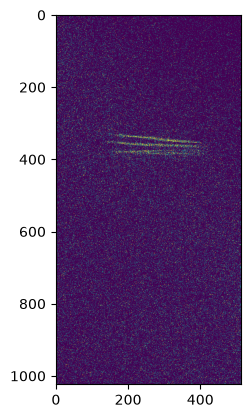

In [9]:
img = sview.data.datasets['UL3_HERFD.h5']['entry/data/data'][135,:,:]
import numpy as np

import matplotlib.pyplot as plt
ilo, ihi = np.percentile(img, [0.5, 99.5])
img = np.clip(img, ilo, ihi)
plt.imshow(img)